In [1]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_score, recall_score, f1_score
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import os
os.makedirs('XGBoost/models', exist_ok=True)

In [2]:
import pandas as pd

path = '/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/Data_Split/' 

# โหลดไฟล์
X_train = pd.read_csv(f'{path}X_train_80.csv')
X_test = pd.read_csv(f'{path}X_test_20.csv')
y_train = pd.read_csv(f'{path}y_train_80.csv').squeeze()
y_test = pd.read_csv(f'{path}y_test_20.csv').squeeze()

print("✅ โหลดชุดข้อมูล 80:20 เรียบร้อย!")
print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")

✅ โหลดชุดข้อมูล 80:20 เรียบร้อย!
Train shape: (8000, 20)
Test shape: (2000, 20)


------------------------------
Baseline Model: XGBoost (corrected)
------------------------------


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [00:58:13] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [00:58:13] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [00:58:13] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [00:58:14] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


------------------------------
Cross-Validation Scores (Total 5 Folds):
------------------------------
Fold 1: 0.7969  (79.69%)
Fold 2: 0.7994  (79.94%)
Fold 3: 0.7987  (79.88%)
Fold 4: 0.8013  (80.12%)
Fold 5: 0.7994  (79.94%)
------------------------------
>> Average CV Accuracy: 0.7991 (± 0.0014)
------------------------------
✓ Selected best model from Fold 4
------------------------------

TEST SET PERFORMANCE (Fold 4)
Accuracy:  0.7995
Precision: 0.3333
Recall:    0.0025
F1-Score:  0.0050
ROC-AUC:   0.4715

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.80      1.00      0.89      1600
     Disease       0.33      0.00      0.00       400

    accuracy                           0.80      2000
   macro avg       0.57      0.50      0.45      2000
weighted avg       0.71      0.80      0.71      2000



/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [00:58:14] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


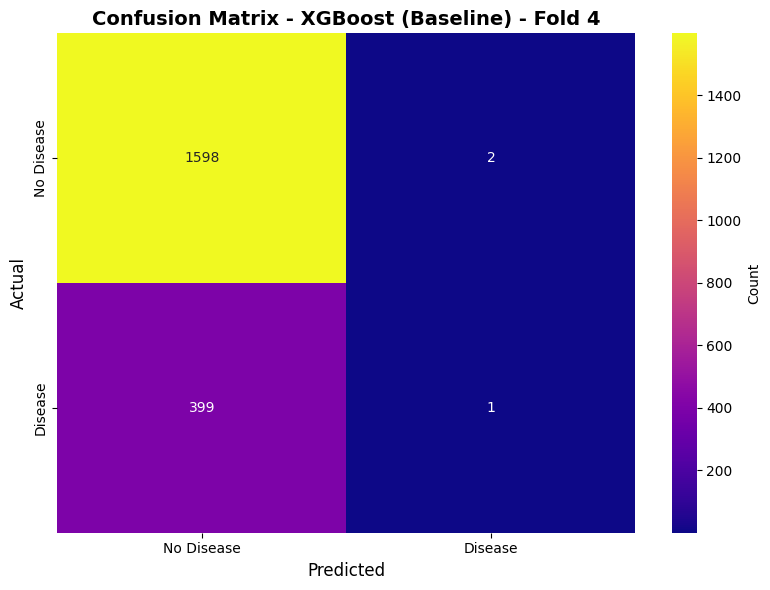


BASELINE RESULTS SUMMARY
Model               : XGBoost
Sampling            : None (Baseline)
Best_Fold           : 4
CV_Accuracy         : 0.7991
CV_Std              : 0.0014
Test_Accuracy       : 0.7995
Precision           : 0.3333
Recall              : 0.0025
F1_Score            : 0.0050
ROC_AUC             : 0.4715
✓ Saved: XGBoost/models/XGBoost_baseline_fold4.pkl


In [3]:
# Corrected: XGBoost baseline training, CV (best-fold selection), evaluation, and save
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix
)
import numpy as np
import joblib
import os
import matplotlib.pyplot as plt
import seaborn as sns

print('-' * 30)
print('Baseline Model: XGBoost (corrected)')
print('-' * 30)

# Prepare arrays (handle DataFrame/Series and numpy inputs)
X_train_arr = X_train.values if hasattr(X_train, 'values') else np.array(X_train)
y_train_arr = y_train.values.ravel() if hasattr(y_train, 'values') else np.array(y_train).ravel()
X_test_arr  = X_test.values if hasattr(X_test, 'values') else np.array(X_test)
y_test_arr  = y_test.values.ravel() if hasattr(y_test, 'values') else np.array(y_test).ravel()

# Cross-validation with best-fold selection
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []
best_model_xgb_baseline = None
best_score_xgb_baseline = -1.0
best_fold_idx_xgb_baseline = -1

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train_arr, y_train_arr)):
    X_train_fold, X_val_fold = X_train_arr[train_idx], X_train_arr[val_idx]
    y_train_fold, y_val_fold = y_train_arr[train_idx], y_train_arr[val_idx]

    xgb_fold = XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss'
    )
    xgb_fold.fit(X_train_fold, y_train_fold)

    score = xgb_fold.score(X_val_fold, y_val_fold)
    cv_scores.append(score)

    if score > best_score_xgb_baseline:
        best_model_xgb_baseline = xgb_fold
        best_score_xgb_baseline = score
        best_fold_idx_xgb_baseline = fold + 1

print('-' * 30)
print(f'Cross-Validation Scores (Total {len(cv_scores)} Folds):')
print('-' * 30)
for i, score in enumerate(cv_scores):
    print(f'Fold {i+1}: {score:.4f}  ({score*100:.2f}%)')
print('-' * 30)
print(f'>> Average CV Accuracy: {np.mean(cv_scores):.4f} (± {np.std(cv_scores):.4f})')
print('-' * 30)

print(f'✓ Selected best model from Fold {best_fold_idx_xgb_baseline}')
print('-' * 30)

# Predictions using best-fold model
y_pred = best_model_xgb_baseline.predict(X_test_arr)
if hasattr(best_model_xgb_baseline, 'predict_proba'):
    y_pred_proba = best_model_xgb_baseline.predict_proba(X_test_arr)[:, 1]
else:
    y_pred_proba = best_model_xgb_baseline.decision_function(X_test_arr)

# Compute test metrics
test_accuracy = accuracy_score(y_test_arr, y_pred)
test_precision = precision_score(y_test_arr, y_pred, zero_division=0)
test_recall = recall_score(y_test_arr, y_pred, zero_division=0)
test_f1 = f1_score(y_test_arr, y_pred, zero_division=0)
test_roc_auc = roc_auc_score(y_test_arr, y_pred_proba)

print('\n' + '=' * 50)
print('TEST SET PERFORMANCE (Fold {})'.format(best_fold_idx_xgb_baseline))
print('=' * 50)
print(f'Accuracy:  {test_accuracy:.4f}')
print(f'Precision: {test_precision:.4f}')
print(f'Recall:    {test_recall:.4f}')
print(f'F1-Score:  {test_f1:.4f}')
print(f'ROC-AUC:   {test_roc_auc:.4f}')
print('=' * 50)

print('\nClassification Report:')
print(classification_report(y_test_arr, y_pred, target_names=['No Disease', 'Disease']))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test_arr, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='plasma', 
            xticklabels=['No Disease', 'Disease'], 
            yticklabels=['No Disease', 'Disease'],
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('Confusion Matrix - XGBoost (Baseline) - Fold {}'.format(best_fold_idx_xgb_baseline), fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary dictionary
xgb_baseline_results = {
    'Model': 'XGBoost',
    'Sampling': 'None (Baseline)',
    'Best_Fold': best_fold_idx_xgb_baseline,
    'CV_Accuracy': np.mean(cv_scores),
    'CV_Std': np.std(cv_scores),
    'Test_Accuracy': test_accuracy,
    'Precision': test_precision,
    'Recall': test_recall,
    'F1_Score': test_f1,
    'ROC_AUC': test_roc_auc
}

print('\n' + '=' * 50)
print('BASELINE RESULTS SUMMARY')
print('=' * 50)
for key, value in xgb_baseline_results.items():
    if isinstance(value, float):
        print(f'{key:20s}: {value:.4f}')
    else:
        print(f'{key:20s}: {value}')
print('=' * 50)

# Ensure save directory exists and save model
os.makedirs('XGBoost/models', exist_ok=True)
model_path = f'XGBoost/models/XGBoost_baseline_fold{best_fold_idx_xgb_baseline}.pkl'
joblib.dump(best_model_xgb_baseline, model_path)
print(f'✓ Saved: {model_path}')

------------------------------
XGBoost + SMOTE
------------------------------
Original training set size: 8000
After SMOTE training set size: 12800
Original class distribution: {0: np.int64(6400), 1: np.int64(1600)}
After SMOTE class distribution: {0: np.int64(6400), 1: np.int64(6400)}
------------------------------


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


------------------------------
Cross-Validation Scores (Total 5 Folds):
------------------------------
Fold 1: 0.7950  (79.50%)
Fold 2: 0.7981  (79.81%)
Fold 3: 0.7937  (79.38%)
Fold 4: 0.7987  (79.88%)
Fold 5: 0.7969  (79.69%)
------------------------------
>> Average CV Accuracy: 0.7965 (± 0.0019)
------------------------------
✓ Selected best model from Fold 4
------------------------------

TEST SET PERFORMANCE (SMOTE) - Fold 4
Accuracy:  0.7980
Precision: 0.1667
Recall:    0.0025
F1-Score:  0.0049
ROC-AUC:   0.4953

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.80      1.00      0.89      1600
     Disease       0.17      0.00      0.00       400

    accuracy                           0.80      2000
   macro avg       0.48      0.50      0.45      2000
weighted avg       0.67      0.80      0.71      2000



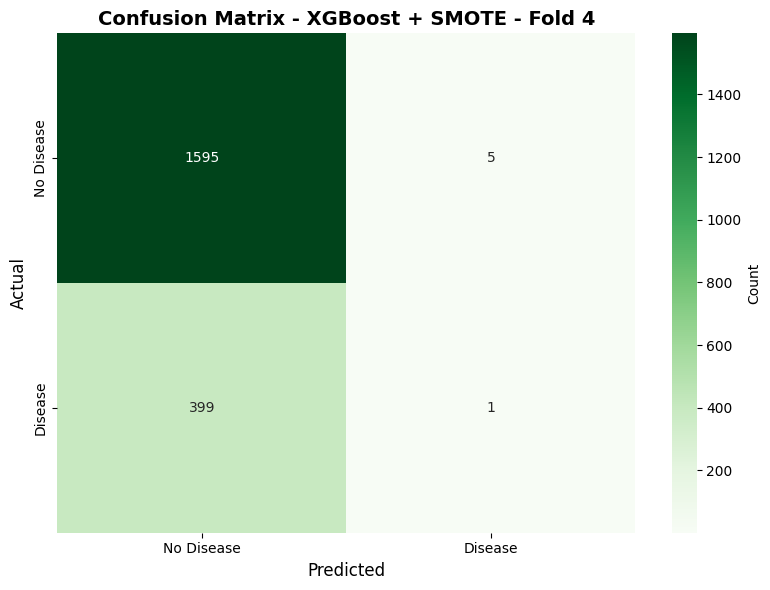


SMOTE RESULTS SUMMARY
Model               : XGBoost
Sampling            : SMOTE
Best_Fold           : 4
CV_Accuracy         : 0.7965
CV_Std              : 0.0019
Test_Accuracy       : 0.7980
Precision           : 0.1667
Recall              : 0.0025
F1_Score            : 0.0049
ROC_AUC             : 0.4953
✓ Saved: XGBoost/models/XGBoost_smote_fold4.pkl
✓ Saved: XGBoost/models/smote_sampler_xgb.pkl


In [4]:
from imblearn.over_sampling import SMOTE

print("-" * 30)
print('XGBoost + SMOTE')
print("-" * 30)

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Apply SMOTE to training data
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train.values.ravel())

print(f"Original training set size: {len(X_train)}")
print(f"After SMOTE training set size: {len(X_train_smote)}")
print(f"Original class distribution: {dict(pd.Series(y_train.values.ravel()).value_counts())}")
print(f"After SMOTE class distribution: {dict(pd.Series(y_train_smote).value_counts())}")
print("-" * 30)

# Cross-validation with SMOTE and best-fold selection
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []
best_model_xgb_smote = None
best_score_xgb_smote = -1.0
best_fold_idx_xgb_smote = -1

X_train_np = X_train.values if hasattr(X_train, 'values') else X_train
y_train_np = y_train.values.ravel() if hasattr(y_train, 'values') else y_train

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train_np, y_train_np)):
    X_train_fold, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_train_fold, y_val_fold = y_train_np[train_idx], y_train_np[val_idx]
    
    try:
        X_train_fold_smote, y_train_fold_smote = smote.fit_resample(X_train_fold, y_train_fold)
        
        xgb_fold = XGBClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=6,
            random_state=42,
            eval_metric='logloss'
        )
        xgb_fold.fit(X_train_fold_smote, y_train_fold_smote)
        score = xgb_fold.score(X_val_fold, y_val_fold)
        cv_scores.append(score)
        
        # Track best fold
        if score > best_score_xgb_smote:
            best_model_xgb_smote = xgb_fold
            best_score_xgb_smote = score
            best_fold_idx_xgb_smote = fold + 1
    except ValueError as e:
        print(f"Warning in fold: {e}")
        continue

print("-" * 30)
print(f"Cross-Validation Scores (Total {len(cv_scores)} Folds):")
print("-" * 30)
for i, score in enumerate(cv_scores):
    print(f"Fold {i+1}: {score:.4f}  ({score*100:.2f}%)")
print("-" * 30)
print(f'>> Average CV Accuracy: {np.mean(cv_scores):.4f} (± {np.std(cv_scores):.4f})')
print("-" * 30)

# Use best fold model for test evaluation
print(f"✓ Selected best model from Fold {best_fold_idx_xgb_smote}")
print("-" * 30)

X_test_np = X_test.values if hasattr(X_test, 'values') else X_test

# Predictions using best-fold model
y_pred = best_model_xgb_smote.predict(X_test_np)
y_pred_proba = best_model_xgb_smote.predict_proba(X_test_np)[:, 1]

# Test set performance
test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)
test_roc_auc = roc_auc_score(y_test, y_pred_proba)

print("\n" + "=" * 50)
print("TEST SET PERFORMANCE (SMOTE) - Fold {}".format(best_fold_idx_xgb_smote))
print("=" * 50)
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1-Score:  {test_f1:.4f}")
print(f"ROC-AUC:   {test_roc_auc:.4f}")
print("=" * 50)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Disease', 'Disease']))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['No Disease', 'Disease'], 
            yticklabels=['No Disease', 'Disease'],
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('Confusion Matrix - XGBoost + SMOTE - Fold {}'.format(best_fold_idx_xgb_smote), fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary dictionary
xgb_smote_results = {
    'Model': 'XGBoost',
    'Sampling': 'SMOTE',
    'Best_Fold': best_fold_idx_xgb_smote,
    'CV_Accuracy': np.mean(cv_scores),
    'CV_Std': np.std(cv_scores),
    'Test_Accuracy': test_accuracy,
    'Precision': test_precision,
    'Recall': test_recall,
    'F1_Score': test_f1,
    'ROC_AUC': test_roc_auc
}

print("\n" + "=" * 50)
print("SMOTE RESULTS SUMMARY")
print("=" * 50)
for key, value in xgb_smote_results.items():
    if isinstance(value, float):
        print(f"{key:20s}: {value:.4f}")
    else:
        print(f"{key:20s}: {value}")
print("=" * 50)

# Save best fold model and sampler
joblib.dump(best_model_xgb_smote, 'XGBoost/models/XGBoost_smote_fold{}.pkl'.format(best_fold_idx_xgb_smote))
joblib.dump(smote, 'XGBoost/models/smote_sampler_xgb.pkl')
print("✓ Saved: XGBoost/models/XGBoost_smote_fold{}.pkl".format(best_fold_idx_xgb_smote))
print("✓ Saved: XGBoost/models/smote_sampler_xgb.pkl")

------------------------------
XGBoost + ADASYN
------------------------------
Original training set size: 8000
After ADASYN training set size: 12824
Original class distribution: {0: np.int64(6400), 1: np.int64(1600)}
After ADASYN class distribution: {1: np.int64(6424), 0: np.int64(6400)}
------------------------------


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


------------------------------
Cross-Validation Scores (Total 5 Folds):
------------------------------
Fold 1: 0.7969  (79.69%)
Fold 2: 0.7981  (79.81%)
Fold 3: 0.7981  (79.81%)
Fold 4: 0.7963  (79.62%)
Fold 5: 0.7975  (79.75%)
------------------------------
>> Average CV Accuracy: 0.7974 (± 0.0007)
------------------------------
✓ Selected best model from Fold 2
------------------------------

TEST SET PERFORMANCE (ADASYN) - Fold 2
Accuracy:  0.7960
Precision: 0.0000
Recall:    0.0000
F1-Score:  0.0000
ROC-AUC:   0.4889

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.80      0.99      0.89      1600
     Disease       0.00      0.00      0.00       400

    accuracy                           0.80      2000
   macro avg       0.40      0.50      0.44      2000
weighted avg       0.64      0.80      0.71      2000



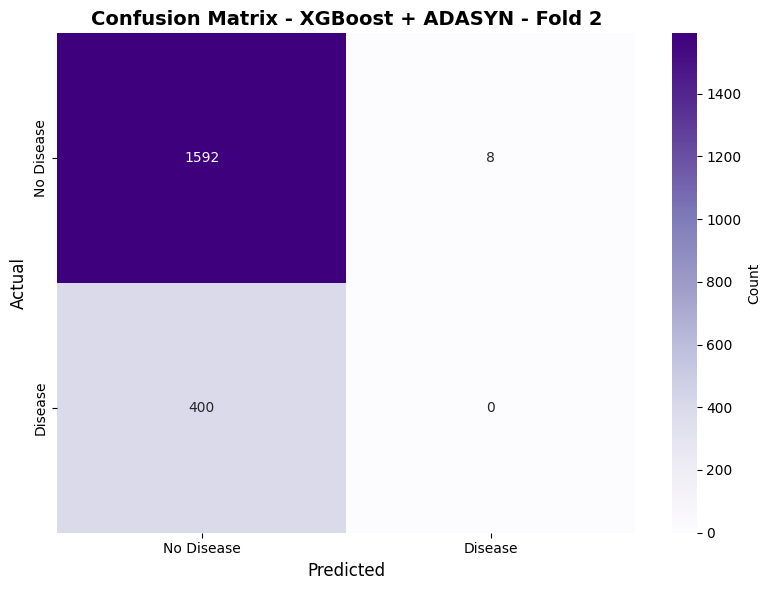


ADASYN RESULTS SUMMARY
Model               : XGBoost
Sampling            : ADASYN
Best_Fold           : 2
CV_Accuracy         : 0.7974
CV_Std              : 0.0007
Test_Accuracy       : 0.7960
Precision           : 0.0000
Recall              : 0.0000
F1_Score            : 0.0000
ROC_AUC             : 0.4889
✓ Saved: XGBoost/models/XGBoost_adasyn_fold2.pkl
✓ Saved: XGBoost/models/adasyn_sampler_xgb.pkl


In [5]:
from imblearn.over_sampling import ADASYN

print("-" * 30)
print('XGBoost + ADASYN')
print("-" * 30)

# Initialize ADASYN
adasyn = ADASYN(random_state=42, n_neighbors=5)

# Apply ADASYN to training data
X_train_adasyn, y_train_adasyn = adasyn.fit_resample(X_train, y_train.values.ravel())

print(f"Original training set size: {len(X_train)}")
print(f"After ADASYN training set size: {len(X_train_adasyn)}")
print(f"Original class distribution: {dict(pd.Series(y_train.values.ravel()).value_counts())}")
print(f"After ADASYN class distribution: {dict(pd.Series(y_train_adasyn).value_counts())}")
print("-" * 30)

# Cross-validation with ADASYN and best-fold selection
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []
best_model_xgb_adasyn = None
best_score_xgb_adasyn = -1.0
best_fold_idx_xgb_adasyn = -1

X_train_np = X_train.values if hasattr(X_train, 'values') else X_train
y_train_np = y_train.values.ravel() if hasattr(y_train, 'values') else y_train

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train_np, y_train_np)):
    X_train_fold, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_train_fold, y_val_fold = y_train_np[train_idx], y_train_np[val_idx]
    
    try:
        X_train_fold_adasyn, y_train_fold_adasyn = adasyn.fit_resample(X_train_fold, y_train_fold)
        
        xgb_fold = XGBClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=6,
            random_state=42,
            eval_metric='logloss'
        )
        xgb_fold.fit(X_train_fold_adasyn, y_train_fold_adasyn)
        score = xgb_fold.score(X_val_fold, y_val_fold)
        cv_scores.append(score)
        
        # Track best fold
        if score > best_score_xgb_adasyn:
            best_model_xgb_adasyn = xgb_fold
            best_score_xgb_adasyn = score
            best_fold_idx_xgb_adasyn = fold + 1
    except ValueError as e:
        print(f"Warning in fold: {e}")
        continue

print("-" * 30)
print(f"Cross-Validation Scores (Total {len(cv_scores)} Folds):")
print("-" * 30)
for i, score in enumerate(cv_scores):
    print(f"Fold {i+1}: {score:.4f}  ({score*100:.2f}%)")
print("-" * 30)
print(f'>> Average CV Accuracy: {np.mean(cv_scores):.4f} (± {np.std(cv_scores):.4f})')
print("-" * 30)

# Use best fold model for test evaluation
print(f"✓ Selected best model from Fold {best_fold_idx_xgb_adasyn}")
print("-" * 30)

X_test_np = X_test.values if hasattr(X_test, 'values') else X_test

# Predictions using best-fold model
y_pred = best_model_xgb_adasyn.predict(X_test_np)
y_pred_proba = best_model_xgb_adasyn.predict_proba(X_test_np)[:, 1]

# Test set performance
test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)
test_roc_auc = roc_auc_score(y_test, y_pred_proba)

print("\n" + "=" * 50)
print("TEST SET PERFORMANCE (ADASYN) - Fold {}".format(best_fold_idx_xgb_adasyn))
print("=" * 50)
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1-Score:  {test_f1:.4f}")
print(f"ROC-AUC:   {test_roc_auc:.4f}")
print("=" * 50)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Disease', 'Disease']))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Purples', 
            xticklabels=['No Disease', 'Disease'], 
            yticklabels=['No Disease', 'Disease'],
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('Confusion Matrix - XGBoost + ADASYN - Fold {}'.format(best_fold_idx_xgb_adasyn), fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary dictionary
xgb_adasyn_results = {
    'Model': 'XGBoost',
    'Sampling': 'ADASYN',
    'Best_Fold': best_fold_idx_xgb_adasyn,
    'CV_Accuracy': np.mean(cv_scores),
    'CV_Std': np.std(cv_scores),
    'Test_Accuracy': test_accuracy,
    'Precision': test_precision,
    'Recall': test_recall,
    'F1_Score': test_f1,
    'ROC_AUC': test_roc_auc
}

print("\n" + "=" * 50)
print("ADASYN RESULTS SUMMARY")
print("=" * 50)
for key, value in xgb_adasyn_results.items():
    if isinstance(value, float):
        print(f"{key:20s}: {value:.4f}")
    else:
        print(f"{key:20s}: {value}")
print("=" * 50)

# Save best fold model and sampler
joblib.dump(best_model_xgb_adasyn, 'XGBoost/models/XGBoost_adasyn_fold{}.pkl'.format(best_fold_idx_xgb_adasyn))
joblib.dump(adasyn, 'XGBoost/models/adasyn_sampler_xgb.pkl')
print("✓ Saved: XGBoost/models/XGBoost_adasyn_fold{}.pkl".format(best_fold_idx_xgb_adasyn))
print("✓ Saved: XGBoost/models/adasyn_sampler_xgb.pkl")

------------------------------
XGBoost + RandomUnderSampler
------------------------------
Original training set size: 8000
After RUS training set size: 3200
Original class distribution: {0: np.int64(6400), 1: np.int64(1600)}
After RUS class distribution: {0: np.int64(1600), 1: np.int64(1600)}
------------------------------


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._

/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._

------------------------------
Cross-Validation Scores (Total 5 Folds):
------------------------------
Fold 1: 0.5175  (51.75%)
Fold 2: 0.5075  (50.75%)
Fold 3: 0.4800  (48.00%)
Fold 4: 0.5094  (50.94%)
Fold 5: 0.4575  (45.75%)
------------------------------
>> Average CV Accuracy: 0.4944 (± 0.0224)
------------------------------
✓ Selected best model from Fold 1
------------------------------

TEST SET PERFORMANCE (RUS) - Fold 1
Accuracy:  0.4985
Precision: 0.1927
Recall:    0.4725
F1-Score:  0.2737
ROC-AUC:   0.4943

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.79      0.51      0.62      1600
     Disease       0.19      0.47      0.27       400

    accuracy                           0.50      2000
   macro avg       0.49      0.49      0.45      2000
weighted avg       0.67      0.50      0.55      2000



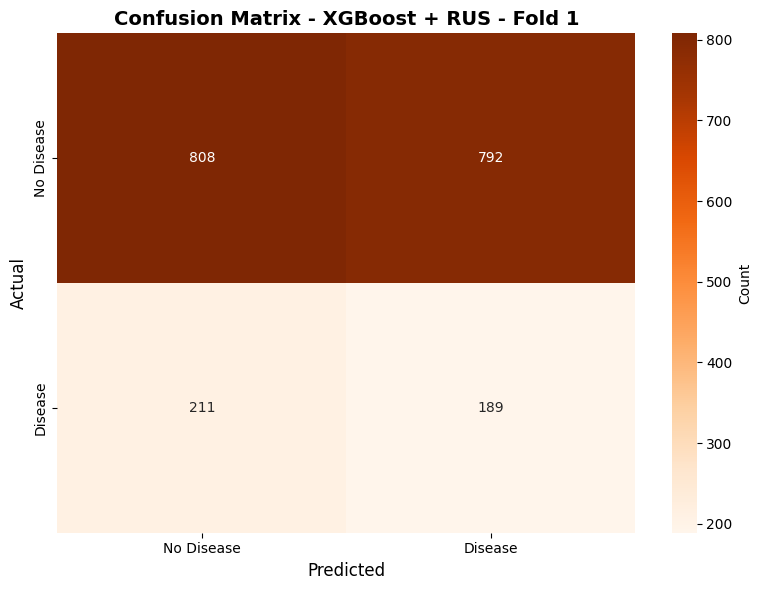


RUS RESULTS SUMMARY
Model               : XGBoost
Sampling            : RandomUnderSampler
Best_Fold           : 1
CV_Accuracy         : 0.4944
CV_Std              : 0.0224
Test_Accuracy       : 0.4985
Precision           : 0.1927
Recall              : 0.4725
F1_Score            : 0.2737
ROC_AUC             : 0.4943
✓ Saved: XGBoost/models/XGBoost_rus_fold1.pkl
✓ Saved: XGBoost/models/rus_sampler_xgb.pkl


In [6]:
from imblearn.under_sampling import RandomUnderSampler

print("-" * 30)
print('XGBoost + RandomUnderSampler')
print("-" * 30)

# Initialize RUS
rus = RandomUnderSampler(random_state=42)

# Apply RUS to training data
X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train.values.ravel())

print(f"Original training set size: {len(X_train)}")
print(f"After RUS training set size: {len(X_train_rus)}")
print(f"Original class distribution: {dict(pd.Series(y_train.values.ravel()).value_counts())}")
print(f"After RUS class distribution: {dict(pd.Series(y_train_rus).value_counts())}")
print("-" * 30)

# Cross-validation with RUS and best-fold selection
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []
best_model_xgb_rus = None
best_score_xgb_rus = -1.0
best_fold_idx_xgb_rus = -1

X_train_np = X_train.values if hasattr(X_train, 'values') else X_train
y_train_np = y_train.values.ravel() if hasattr(y_train, 'values') else y_train

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train_np, y_train_np)):
    X_train_fold, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_train_fold, y_val_fold = y_train_np[train_idx], y_train_np[val_idx]
    
    X_train_fold_rus, y_train_fold_rus = rus.fit_resample(X_train_fold, y_train_fold)
    
    xgb_fold = XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        random_state=42,
        eval_metric='logloss'
    )
    xgb_fold.fit(X_train_fold_rus, y_train_fold_rus)
    score = xgb_fold.score(X_val_fold, y_val_fold)
    cv_scores.append(score)
    
    # Track best fold
    if score > best_score_xgb_rus:
        best_model_xgb_rus = xgb_fold
        best_score_xgb_rus = score
        best_fold_idx_xgb_rus = fold + 1

print("-" * 30)
print(f"Cross-Validation Scores (Total {len(cv_scores)} Folds):")
print("-" * 30)
for i, score in enumerate(cv_scores):
    print(f"Fold {i+1}: {score:.4f}  ({score*100:.2f}%)")
print("-" * 30)
print(f'>> Average CV Accuracy: {np.mean(cv_scores):.4f} (± {np.std(cv_scores):.4f})')
print("-" * 30)

# Use best fold model for test evaluation
print(f"✓ Selected best model from Fold {best_fold_idx_xgb_rus}")
print("-" * 30)

X_test_np = X_test.values if hasattr(X_test, 'values') else X_test

# Predictions using best-fold model
y_pred = best_model_xgb_rus.predict(X_test_np)
y_pred_proba = best_model_xgb_rus.predict_proba(X_test_np)[:, 1]

# Test set performance
test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)
test_roc_auc = roc_auc_score(y_test, y_pred_proba)

print("\n" + "=" * 50)
print("TEST SET PERFORMANCE (RUS) - Fold {}".format(best_fold_idx_xgb_rus))
print("=" * 50)
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1-Score:  {test_f1:.4f}")
print(f"ROC-AUC:   {test_roc_auc:.4f}")
print("=" * 50)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Disease', 'Disease']))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['No Disease', 'Disease'], 
            yticklabels=['No Disease', 'Disease'],
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('Confusion Matrix - XGBoost + RUS - Fold {}'.format(best_fold_idx_xgb_rus), fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary dictionary
xgb_rus_results = {
    'Model': 'XGBoost',
    'Sampling': 'RandomUnderSampler',
    'Best_Fold': best_fold_idx_xgb_rus,
    'CV_Accuracy': np.mean(cv_scores),
    'CV_Std': np.std(cv_scores),
    'Test_Accuracy': test_accuracy,
    'Precision': test_precision,
    'Recall': test_recall,
    'F1_Score': test_f1,
    'ROC_AUC': test_roc_auc
}

print("\n" + "=" * 50)
print("RUS RESULTS SUMMARY")
print("=" * 50)
for key, value in xgb_rus_results.items():
    if isinstance(value, float):
        print(f"{key:20s}: {value:.4f}")
    else:
        print(f"{key:20s}: {value}")
print("=" * 50)

# Save best fold model and sampler
joblib.dump(best_model_xgb_rus, 'XGBoost/models/XGBoost_rus_fold{}.pkl'.format(best_fold_idx_xgb_rus))
joblib.dump(rus, 'XGBoost/models/rus_sampler_xgb.pkl')
print("✓ Saved: XGBoost/models/XGBoost_rus_fold{}.pkl".format(best_fold_idx_xgb_rus))
print("✓ Saved: XGBoost/models/rus_sampler_xgb.pkl")

------------------------------
XGBoost + NearMiss
------------------------------
Original training set size: 8000
------------------------------


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [00:58:17] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Fold 1: 0.3875


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [00:58:18] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Fold 2: 0.3944


...

Fold 3: 0.4031


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [00:58:18] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Fold 4: 0.3912


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [00:58:18] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Fold 5: 0.3781
------------------------------
Cross-Validation Scores (Total 5 Folds):
------------------------------
Fold 1: 0.3875  (38.75%)
Fold 2: 0.3944  (39.44%)
Fold 3: 0.4031  (40.31%)
Fold 4: 0.3912  (39.12%)
Fold 5: 0.3781  (37.81%)
------------------------------
>> Average CV Accuracy: 0.3909 (± 0.0082)
------------------------------
✓ Selected best model from Fold 3
------------------------------

TEST SET PERFORMANCE (NearMiss) - Fold 3
Accuracy:  0.3910
Precision: 0.1993
Recall:    0.6775
F1-Score:  0.3080
ROC-AUC:   0.5086


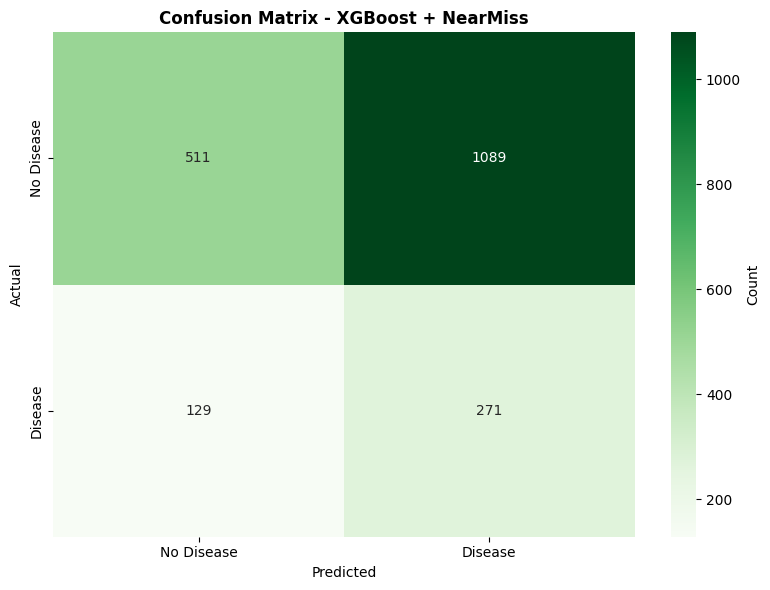

✓ Saved: XGBoost/models/XGBoost_nearmiss_fold3.pkl
✓ Saved: XGBoost/models/nearmiss_sampler_xgb.pkl
✓ Saved model


In [7]:
from imblearn.under_sampling import NearMiss
from xgboost import XGBClassifier

print("-" * 30)
print('XGBoost + NearMiss')
print("-" * 30)

# Prepare arrays
X_train_arr = X_train.values if hasattr(X_train, 'values') else np.array(X_train)
y_train_arr = y_train.values.ravel() if hasattr(y_train, 'values') else np.array(y_train).ravel()
X_test_arr = X_test.values if hasattr(X_test, 'values') else np.array(X_test)
y_test_arr = y_test.values.ravel() if hasattr(y_test, 'values') else np.array(y_test).ravel()

# 1. Initialize NearMiss sampler
nm = NearMiss(version=2)

print(f"Original training set size: {len(X_train_arr)}")
print("-" * 30)

# 2. Cross-validation with NearMiss (resample only training folds)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []
best_model_xgb_nearmiss = None
best_score_xgb_nearmiss = -1.0
best_fold_idx_xgb_nearmiss = -1

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train_arr, y_train_arr)):
    X_train_fold, X_val_fold = X_train_arr[train_idx], X_train_arr[val_idx]
    y_train_fold, y_val_fold = y_train_arr[train_idx], y_train_arr[val_idx]

    try:
        X_train_fold_nearmiss, y_train_fold_nearmiss = nm.fit_resample(X_train_fold, y_train_fold)

        xgb_fold = XGBClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=6,
            random_state=42,
            use_label_encoder=False,
            eval_metric='logloss'
        )
        xgb_fold.fit(X_train_fold_nearmiss, y_train_fold_nearmiss)

        score = xgb_fold.score(X_val_fold, y_val_fold)
        cv_scores.append(score)
        print(f"Fold {fold+1}: {score:.4f}")

        if score > best_score_xgb_nearmiss:
            best_model_xgb_nearmiss = xgb_fold
            best_score_xgb_nearmiss = score
            best_fold_idx_xgb_nearmiss = fold + 1
    except ValueError as e:
        print(f"Warning in fold {fold+1}: {e}")
        continue

if len(cv_scores) == 0:
    raise RuntimeError('No successful CV folds for NearMiss; check class distribution and parameters')

print("-" * 30)
print(f"Cross-Validation Scores (Total {len(cv_scores)} Folds):")
print("-" * 30)
for i, score in enumerate(cv_scores):
    print(f"Fold {i+1}: {score:.4f}  ({score*100:.2f}%)")
print("-" * 30)
print(f'>> Average CV Accuracy: {np.mean(cv_scores):.4f} (± {np.std(cv_scores):.4f})')
print("-" * 30)

# Use best fold model for test evaluation
print(f"✓ Selected best model from Fold {best_fold_idx_xgb_nearmiss}")
print("-" * 30)

# Predictions using best-fold model
y_pred = best_model_xgb_nearmiss.predict(X_test_arr)
if hasattr(best_model_xgb_nearmiss, 'predict_proba'):
    y_pred_proba = best_model_xgb_nearmiss.predict_proba(X_test_arr)[:, 1]
else:
    y_pred_proba = best_model_xgb_nearmiss.decision_function(X_test_arr)

# Test set performance
test_accuracy = accuracy_score(y_test_arr, y_pred)
test_precision = precision_score(y_test_arr, y_pred, zero_division=0)
test_recall = recall_score(y_test_arr, y_pred, zero_division=0)
test_f1 = f1_score(y_test_arr, y_pred, zero_division=0)
test_roc_auc = roc_auc_score(y_test_arr, y_pred_proba)

print("\n" + "=" * 50)
print("TEST SET PERFORMANCE (NearMiss) - Fold {}".format(best_fold_idx_xgb_nearmiss))
print("=" * 50)
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1-Score:  {test_f1:.4f}")
print(f"ROC-AUC:   {test_roc_auc:.4f}")
print("=" * 50)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test_arr, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['No Disease', 'Disease'], 
            yticklabels=['No Disease', 'Disease'],
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - XGBoost + NearMiss', fontweight='bold')
plt.tight_layout()
plt.show()

# Save Results
xgb_nearmiss_results = {
    'Model': 'XGBoost',
    'Sampling': 'NearMiss',
    'Best_Fold': best_fold_idx_xgb_nearmiss,
    'CV_Accuracy': np.mean(cv_scores),
    'CV_Std': np.std(cv_scores),
    'Test_Accuracy': test_accuracy,
    'Precision': test_precision,
    'Recall': test_recall,
    'F1_Score': test_f1,
    'ROC_AUC': test_roc_auc
}

os.makedirs('XGBoost/models', exist_ok=True)
joblib.dump(best_model_xgb_nearmiss, 'XGBoost/models/XGBoost_nearmiss_fold{}.pkl'.format(best_fold_idx_xgb_nearmiss))
joblib.dump(nm, 'XGBoost/models/nearmiss_sampler_xgb.pkl')
print("✓ Saved: XGBoost/models/XGBoost_nearmiss_fold{}.pkl".format(best_fold_idx_xgb_nearmiss))
print("✓ Saved: XGBoost/models/nearmiss_sampler_xgb.pkl")
print("✓ Saved model")

------------------------------
XGBoost + Cluster Centroids
------------------------------
Resampling... (This may take a while ⏳)


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Original size: 8000
After CC size: 3200
------------------------------


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [00:58:19] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


------------------------------
Cross-Validation Scores (Total 5 Folds):
------------------------------
Fold 1: 0.2006  (20.06%)
Fold 2: 0.2013  (20.12%)
Fold 3: 0.2019  (20.19%)
Fold 4: 0.2013  (20.12%)
Fold 5: 0.2019  (20.19%)
------------------------------
>> Average CV Accuracy: 0.2014 (± 0.0005)
------------------------------
TEST SET PERFORMANCE (Cluster Centroids) - Fold 3
Accuracy:  0.2010
Precision: 0.1999
Recall:    0.9975
F1-Score:  0.3331
ROC-AUC:   0.4836


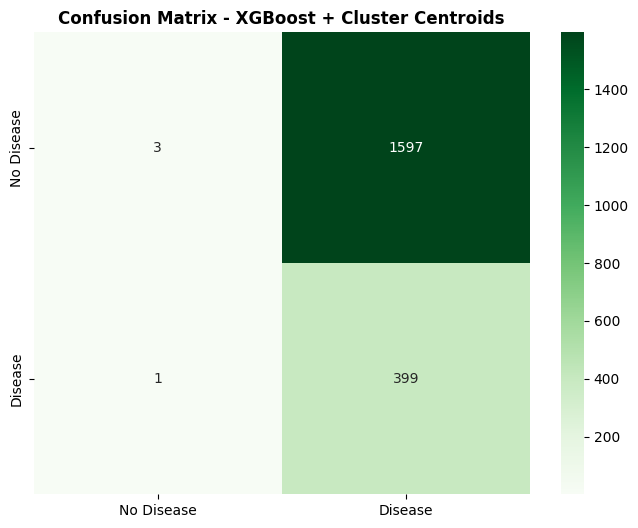

✓ Saved: XGBoost/models/XGBoost_cc_fold3.pkl
✓ Saved: XGBoost/models/cc_sampler_xgb.pkl
✓ Saved model


In [8]:
from imblearn.under_sampling import ClusterCentroids

print("-" * 30)
print('XGBoost + Cluster Centroids')
print("-" * 30)

# 1. Apply Cluster Centroids
cc = ClusterCentroids(random_state=42, voting='soft')
print("Resampling... (This may take a while ⏳)")
X_train_cc, y_train_cc = cc.fit_resample(X_train, y_train.values.ravel())

print(f"Original size: {len(X_train)}")
print(f"After CC size: {len(X_train_cc)}")
print("-" * 30)

# 2. Train Model
xgb_cc = XGBClassifier(
    n_estimators=100, random_state=42,
    use_label_encoder=False, eval_metric='logloss'
)
xgb_cc.fit(X_train_cc, y_train_cc)

# 3. Cross-Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []
best_model_xgb_cc = None
best_score_xgb_cc = -1.0
best_fold_idx_xgb_cc = -1

X_train_np = X_train.values if hasattr(X_train, 'values') else X_train
y_train_np = y_train.values.ravel() if hasattr(y_train, 'values') else y_train

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train_np, y_train_np)):
    X_train_fold, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_train_fold, y_val_fold = y_train_np[train_idx], y_train_np[val_idx]

    try:
        # Apply Cluster Centroids to each fold's training subset
        X_train_fold_cc, y_train_fold_cc = cc.fit_resample(X_train_fold, y_train_fold)

        xgb_fold = XGBClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=6,
            random_state=42,
            eval_metric='logloss'
        )
        xgb_fold.fit(X_train_fold_cc, y_train_fold_cc)
        score = xgb_fold.score(X_val_fold, y_val_fold)
        cv_scores.append(score)

        # Track the best model and score based on cross-validation
        if score > best_score_xgb_cc:
            best_model_xgb_cc = xgb_fold
            best_score_xgb_cc = score
            best_fold_idx_xgb_cc = fold + 1
    except ValueError as e:
        print(f"Warning in fold: {e}")
        continue

print("-" * 30)
print(f"Cross-Validation Scores (Total {len(cv_scores)} Folds):")
print("-" * 30)
for i, score in enumerate(cv_scores):
    print(f"Fold {i+1}: {score:.4f}  ({score*100:.2f}%)")
print("-" * 30)
print(f'>> Average CV Accuracy: {np.mean(cv_scores):.4f} (± {np.std(cv_scores):.4f})')
print("-" * 30)

# Predictions using best model
X_test_np = X_test.values if hasattr(X_test, 'values') else X_test
y_pred = best_model_xgb_cc.predict(X_test_np)
y_pred_proba = best_model_xgb_cc.predict_proba(X_test_np)[:, 1]

# Evaluation Metrics
test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)
test_roc_auc = roc_auc_score(y_test, y_pred_proba)

print("=" * 50)
print(f"TEST SET PERFORMANCE (Cluster Centroids) - Fold {best_fold_idx_xgb_cc}")
print("=" * 50)
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1-Score:  {test_f1:.4f}")
print(f"ROC-AUC:   {test_roc_auc:.4f}")
print("=" * 50)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.title('Confusion Matrix - XGBoost + Cluster Centroids', fontweight='bold')
plt.show()

# Save Results
xgb_cc_results = {
    'Model': 'XGBoost', 'Sampling': 'ClusterCentroids',
    'Best_Fold': best_fold_idx_xgb_cc,
    'CV_Accuracy': np.mean(cv_scores), 'CV_Std': np.std(cv_scores),
    'Test_Accuracy': test_accuracy, 'Precision': test_precision,
    'Recall': test_recall, 'F1_Score': test_f1, 'ROC_AUC': test_roc_auc
}

joblib.dump(xgb_cc, 'XGBoost/models/XGB_cluster_centroids.pkl')
joblib.dump(best_model_xgb_cc, 'XGBoost/models/XGBoost_cc_fold{}.pkl'.format(best_fold_idx_xgb_cc))
joblib.dump(cc, 'XGBoost/models/cc_sampler_xgb.pkl')
print("✓ Saved: XGBoost/models/XGBoost_cc_fold{}.pkl".format(best_fold_idx_xgb_cc))
print("✓ Saved: XGBoost/models/cc_sampler_xgb.pkl")
print("✓ Saved model")

------------------------------
XGBoost + SMOTETomek
------------------------------
Original training set size: 8000
After SMOTETomek training set size: 12772
Original class distribution: {0: np.int64(6400), 1: np.int64(1600)}
After SMOTETomek class distribution: {0: np.int64(6386), 1: np.int64(6386)}
------------------------------


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and i

/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and i

/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and i

/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and i

/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and i

------------------------------
Cross-Validation Scores (Total 5 Folds):
------------------------------
Fold 1: 0.7987  (79.88%)
Fold 2: 0.8000  (80.00%)
Fold 3: 0.7963  (79.62%)
Fold 4: 0.7987  (79.88%)
Fold 5: 0.7963  (79.62%)
------------------------------
>> Average CV Accuracy: 0.7980 (± 0.0015)
------------------------------
✓ Selected best model from Fold 2
------------------------------

TEST SET PERFORMANCE (SMOTETomek) - Fold 2
Accuracy:  0.7965
Precision: 0.2308
Recall:    0.0075
F1-Score:  0.0145
ROC-AUC:   0.4835

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.80      0.99      0.89      1600
     Disease       0.23      0.01      0.01       400

    accuracy                           0.80      2000
   macro avg       0.52      0.50      0.45      2000
weighted avg       0.69      0.80      0.71      2000



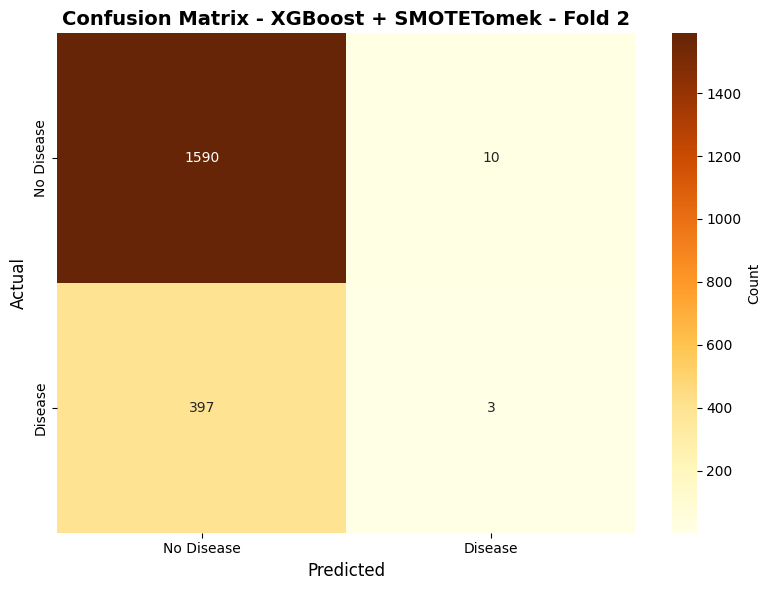


SMOTETomek RESULTS SUMMARY
Model               : XGBoost
Sampling            : SMOTETomek
Best_Fold           : 2
CV_Accuracy         : 0.7980
CV_Std              : 0.0015
Test_Accuracy       : 0.7965
Precision           : 0.2308
Recall              : 0.0075
F1_Score            : 0.0145
ROC_AUC             : 0.4835
✓ Saved: XGBoost/models/XGBoost_smote_tomek_fold2.pkl
✓ Saved: XGBoost/models/smote_tomek_sampler_xgb.pkl


In [9]:
from imblearn.combine import SMOTETomek

print("-" * 30)
print('XGBoost + SMOTETomek')
print("-" * 30)

# Initialize SMOTETomek
smote_tomek = SMOTETomek(random_state=42)

# Apply SMOTETomek to training data
X_train_smote_tomek, y_train_smote_tomek = smote_tomek.fit_resample(X_train, y_train.values.ravel())

print(f"Original training set size: {len(X_train)}")
print(f"After SMOTETomek training set size: {len(X_train_smote_tomek)}")
print(f"Original class distribution: {dict(pd.Series(y_train.values.ravel()).value_counts())}")
print(f"After SMOTETomek class distribution: {dict(pd.Series(y_train_smote_tomek).value_counts())}")
print("-" * 30)

# Cross-validation with SMOTETomek and best-fold selection
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []
best_model_xgb_smote_tomek = None
best_score_xgb_smote_tomek = -1.0
best_fold_idx_xgb_smote_tomek = -1

X_train_np = X_train.values if hasattr(X_train, 'values') else X_train
y_train_np = y_train.values.ravel() if hasattr(y_train, 'values') else y_train

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train_np, y_train_np)):
    X_train_fold, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_train_fold, y_val_fold = y_train_np[train_idx], y_train_np[val_idx]
    
    try:
        X_train_fold_smote_tomek, y_train_fold_smote_tomek = smote_tomek.fit_resample(X_train_fold, y_train_fold)
        
        xgb_fold = XGBClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=6,
            random_state=42,
            eval_metric='logloss'
        )
        xgb_fold.fit(X_train_fold_smote_tomek, y_train_fold_smote_tomek)
        score = xgb_fold.score(X_val_fold, y_val_fold)
        cv_scores.append(score)
        
        # Track best fold
        if score > best_score_xgb_smote_tomek:
            best_model_xgb_smote_tomek = xgb_fold
            best_score_xgb_smote_tomek = score
            best_fold_idx_xgb_smote_tomek = fold + 1
    except ValueError as e:
        print(f"Warning in fold: {e}")
        continue

print("-" * 30)
print(f"Cross-Validation Scores (Total {len(cv_scores)} Folds):")
print("-" * 30)
for i, score in enumerate(cv_scores):
    print(f"Fold {i+1}: {score:.4f}  ({score*100:.2f}%)")
print("-" * 30)
print(f'>> Average CV Accuracy: {np.mean(cv_scores):.4f} (± {np.std(cv_scores):.4f})')
print("-" * 30)

# Use best fold model for test evaluation
print(f"✓ Selected best model from Fold {best_fold_idx_xgb_smote_tomek}")
print("-" * 30)

X_test_np = X_test.values if hasattr(X_test, 'values') else X_test

# Predictions using best-fold model
y_pred = best_model_xgb_smote_tomek.predict(X_test_np)
y_pred_proba = best_model_xgb_smote_tomek.predict_proba(X_test_np)[:, 1]

# Test set performance
test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)
test_roc_auc = roc_auc_score(y_test, y_pred_proba)

print("\n" + "=" * 50)
print("TEST SET PERFORMANCE (SMOTETomek) - Fold {}".format(best_fold_idx_xgb_smote_tomek))
print("=" * 50)
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1-Score:  {test_f1:.4f}")
print(f"ROC-AUC:   {test_roc_auc:.4f}")
print("=" * 50)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Disease', 'Disease']))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='YlOrBr', 
            xticklabels=['No Disease', 'Disease'], 
            yticklabels=['No Disease', 'Disease'],
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('Confusion Matrix - XGBoost + SMOTETomek - Fold {}'.format(best_fold_idx_xgb_smote_tomek), fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary dictionary
xgb_smote_tomek_results = {
    'Model': 'XGBoost',
    'Sampling': 'SMOTETomek',
    'Best_Fold': best_fold_idx_xgb_smote_tomek,
    'CV_Accuracy': np.mean(cv_scores),
    'CV_Std': np.std(cv_scores),
    'Test_Accuracy': test_accuracy,
    'Precision': test_precision,
    'Recall': test_recall,
    'F1_Score': test_f1,
    'ROC_AUC': test_roc_auc
}

print("\n" + "=" * 50)
print("SMOTETomek RESULTS SUMMARY")
print("=" * 50)
for key, value in xgb_smote_tomek_results.items():
    if isinstance(value, float):
        print(f"{key:20s}: {value:.4f}")
    else:
        print(f"{key:20s}: {value}")
print("=" * 50)

# Save best fold model and sampler
joblib.dump(best_model_xgb_smote_tomek, 'XGBoost/models/XGBoost_smote_tomek_fold{}.pkl'.format(best_fold_idx_xgb_smote_tomek))
joblib.dump(smote_tomek, 'XGBoost/models/smote_tomek_sampler_xgb.pkl')
print("✓ Saved: XGBoost/models/XGBoost_smote_tomek_fold{}.pkl".format(best_fold_idx_xgb_smote_tomek))
print("✓ Saved: XGBoost/models/smote_tomek_sampler_xgb.pkl")

------------------------------
XGBoost + SMOTEENN
------------------------------


Original training set size: 8000
After SMOTEENN training set size: 8022
Original class distribution: {0: np.int64(6400), 1: np.int64(1600)}
After SMOTEENN class distribution: {1: np.int64(6043), 0: np.int64(1979)}
------------------------------


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and i

/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and i

/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and i

/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and i

/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and i

------------------------------
Cross-Validation Scores (Total 5 Folds):
------------------------------
Fold 1: 0.5288  (52.88%)
Fold 2: 0.5331  (53.31%)
Fold 3: 0.5044  (50.44%)
Fold 4: 0.5150  (51.50%)
Fold 5: 0.5413  (54.12%)
------------------------------
>> Average CV Accuracy: 0.5245 (± 0.0132)
------------------------------
✓ Selected best model from Fold 5
------------------------------

TEST SET PERFORMANCE (SMOTEENN) - Fold 5
Accuracy:  0.5220
Precision: 0.1945
Recall:    0.4425
F1-Score:  0.2702
ROC-AUC:   0.5048

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.80      0.54      0.64      1600
     Disease       0.19      0.44      0.27       400

    accuracy                           0.52      2000
   macro avg       0.49      0.49      0.46      2000
weighted avg       0.68      0.52      0.57      2000



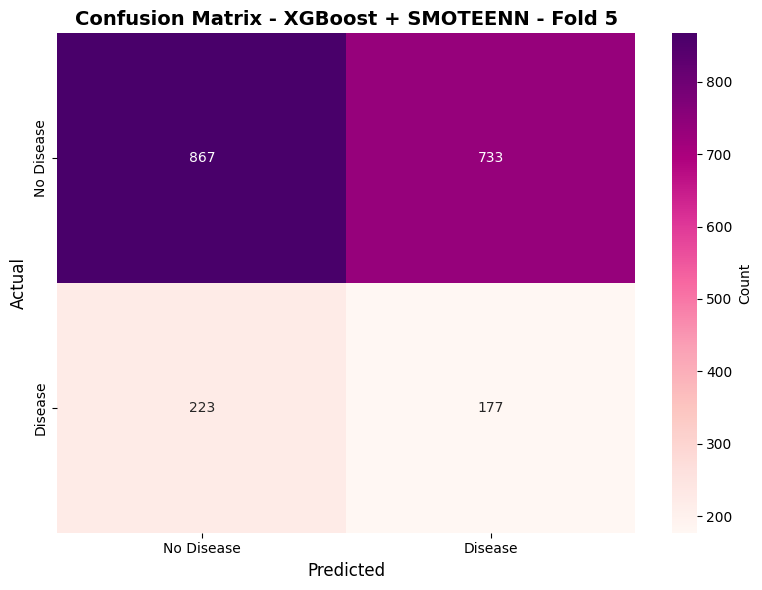


SMOTEENN RESULTS SUMMARY
Model               : XGBoost
Sampling            : SMOTEENN
Best_Fold           : 5
CV_Accuracy         : 0.5245
CV_Std              : 0.0132
Test_Accuracy       : 0.5220
Precision           : 0.1945
Recall              : 0.4425
F1_Score            : 0.2702
ROC_AUC             : 0.5048
✓ Saved: XGBoost/models/XGBoost_smote_enn_fold5.pkl
✓ Saved: XGBoost/models/smote_enn_sampler_xgb.pkl


In [10]:
from imblearn.combine import SMOTEENN

print("-" * 30)
print('XGBoost + SMOTEENN')
print("-" * 30)

# Initialize SMOTEENN
smote_enn = SMOTEENN(random_state=42)

# Apply SMOTEENN to training data
X_train_smote_enn, y_train_smote_enn = smote_enn.fit_resample(X_train, y_train.values.ravel())

print(f"Original training set size: {len(X_train)}")
print(f"After SMOTEENN training set size: {len(X_train_smote_enn)}")
print(f"Original class distribution: {dict(pd.Series(y_train.values.ravel()).value_counts())}")
print(f"After SMOTEENN class distribution: {dict(pd.Series(y_train_smote_enn).value_counts())}")
print("-" * 30)

# Cross-validation with SMOTEENN and best-fold selection
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []
best_model_xgb_smote_enn = None
best_score_xgb_smote_enn = -1.0
best_fold_idx_xgb_smote_enn = -1

X_train_np = X_train.values if hasattr(X_train, 'values') else X_train
y_train_np = y_train.values.ravel() if hasattr(y_train, 'values') else y_train

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train_np, y_train_np)):
    X_train_fold, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_train_fold, y_val_fold = y_train_np[train_idx], y_train_np[val_idx]
    
    try:
        X_train_fold_smote_enn, y_train_fold_smote_enn = smote_enn.fit_resample(X_train_fold, y_train_fold)
        
        xgb_fold = XGBClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=6,
            random_state=42,
            eval_metric='logloss'
        )
        xgb_fold.fit(X_train_fold_smote_enn, y_train_fold_smote_enn)
        score = xgb_fold.score(X_val_fold, y_val_fold)
        cv_scores.append(score)
        
        # Track best fold
        if score > best_score_xgb_smote_enn:
            best_model_xgb_smote_enn = xgb_fold
            best_score_xgb_smote_enn = score
            best_fold_idx_xgb_smote_enn = fold + 1
    except ValueError as e:
        print(f"Warning in fold: {e}")
        continue

print("-" * 30)
print(f"Cross-Validation Scores (Total {len(cv_scores)} Folds):")
print("-" * 30)
for i, score in enumerate(cv_scores):
    print(f"Fold {i+1}: {score:.4f}  ({score*100:.2f}%)")
print("-" * 30)
print(f'>> Average CV Accuracy: {np.mean(cv_scores):.4f} (± {np.std(cv_scores):.4f})')
print("-" * 30)

# Use best fold model for test evaluation
print(f"✓ Selected best model from Fold {best_fold_idx_xgb_smote_enn}")
print("-" * 30)

X_test_np = X_test.values if hasattr(X_test, 'values') else X_test

# Predictions using best-fold model
y_pred = best_model_xgb_smote_enn.predict(X_test_np)
y_pred_proba = best_model_xgb_smote_enn.predict_proba(X_test_np)[:, 1]

# Test set performance
test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)
test_roc_auc = roc_auc_score(y_test, y_pred_proba)

print("\n" + "=" * 50)
print("TEST SET PERFORMANCE (SMOTEENN) - Fold {}".format(best_fold_idx_xgb_smote_enn))
print("=" * 50)
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1-Score:  {test_f1:.4f}")
print(f"ROC-AUC:   {test_roc_auc:.4f}")
print("=" * 50)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Disease', 'Disease']))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='RdPu', 
            xticklabels=['No Disease', 'Disease'], 
            yticklabels=['No Disease', 'Disease'],
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('Confusion Matrix - XGBoost + SMOTEENN - Fold {}'.format(best_fold_idx_xgb_smote_enn), fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary dictionary
xgb_smote_enn_results = {
    'Model': 'XGBoost',
    'Sampling': 'SMOTEENN',
    'Best_Fold': best_fold_idx_xgb_smote_enn,
    'CV_Accuracy': np.mean(cv_scores),
    'CV_Std': np.std(cv_scores),
    'Test_Accuracy': test_accuracy,
    'Precision': test_precision,
    'Recall': test_recall,
    'F1_Score': test_f1,
    'ROC_AUC': test_roc_auc
}

print("\n" + "=" * 50)
print("SMOTEENN RESULTS SUMMARY")
print("=" * 50)
for key, value in xgb_smote_enn_results.items():
    if isinstance(value, float):
        print(f"{key:20s}: {value:.4f}")
    else:
        print(f"{key:20s}: {value}")
print("=" * 50)

# Save best fold model and sampler
joblib.dump(best_model_xgb_smote_enn, 'XGBoost/models/XGBoost_smote_enn_fold{}.pkl'.format(best_fold_idx_xgb_smote_enn))
joblib.dump(smote_enn, 'XGBoost/models/smote_enn_sampler_xgb.pkl')
print("✓ Saved: XGBoost/models/XGBoost_smote_enn_fold{}.pkl".format(best_fold_idx_xgb_smote_enn))
print("✓ Saved: XGBoost/models/smote_enn_sampler_xgb.pkl")

------------------------------
XGBoost + ADASYN + Tomek Links
------------------------------
Resampling with ADASYN + Tomek...
Original size: 8000
After ADASYN+Tomek size: 12821
------------------------------


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [00:58:25] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


------------------------------
Cross-Validation Scores (Total 5 Folds):
------------------------------
Fold 1: 0.7981  (79.81%)
Fold 2: 0.7975  (79.75%)
Fold 3: 0.7981  (79.81%)
Fold 4: 0.7981  (79.81%)
Fold 5: 0.7975  (79.75%)
------------------------------
>> Average CV Accuracy: 0.7979
------------------------------
------------------------------
>> Average CV Accuracy: 0.7979 (± 0.0003)
------------------------------
✓ Selected best model from Fold 1
------------------------------

TEST SET PERFORMANCE (ADASYN + Tomek) - Fold 1
Accuracy:  0.7985
Precision: 0.2857
Recall:    0.0050
F1-Score:  0.0098
ROC-AUC:   0.4813


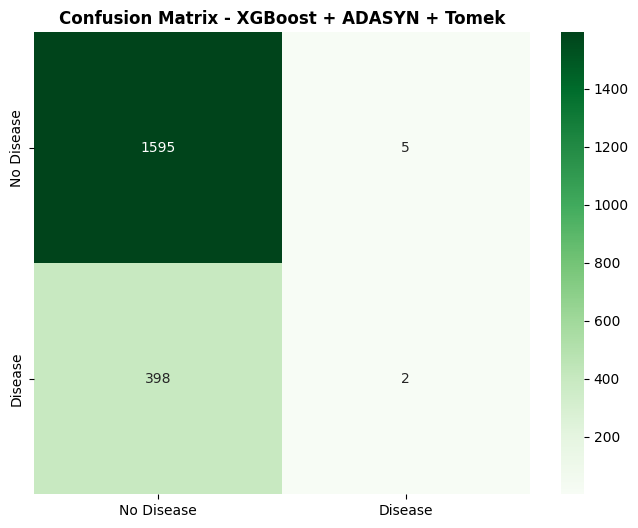

✓ Saved: XGBoost/models/XGBoost_adasyn_tomek_fold1.pkl
✓ Saved: XGBoost/models/adasyn_tomek_sampler_xgb.pkl
✓ Saved model


In [11]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import ADASYN
from imblearn.under_sampling import TomekLinks

print("-" * 30)
print('XGBoost + ADASYN + Tomek Links')
print("-" * 30)

# 1. Apply Pipeline
pipe_at = ImbPipeline([
    ('adasyn', ADASYN(random_state=42)),
    ('tomek', TomekLinks())
])
print("Resampling with ADASYN + Tomek...")
X_train_at, y_train_at = pipe_at.fit_resample(X_train, y_train.values.ravel())

print(f"Original size: {len(X_train)}")
print(f"After ADASYN+Tomek size: {len(X_train_at)}")
print("-" * 30)

# 2. Train Model
xgb_at = XGBClassifier(
    n_estimators=100, random_state=42,
    use_label_encoder=False, eval_metric='logloss'
)
xgb_at.fit(X_train_at, y_train_at)

# 3. Cross-Validation
cv_scores = []

# Cross-validation with ADASYN+Tomek and best-fold selection
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []
best_model_xgb_adasyn_tomek = None
best_score_xgb_adasyn_tomek = -1.0
best_fold_idx_xgb_adasyn_tomek = -1

X_train_np = X_train.values if hasattr(X_train, 'values') else X_train
y_train_np = y_train.values.ravel() if hasattr(y_train, 'values') else y_train

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train_np, y_train_np)):
    X_train_fold, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_train_fold, y_val_fold = y_train_np[train_idx], y_train_np[val_idx]
    
    try:
        X_train_fold_at, y_train_fold_at = pipe_at.fit_resample(X_train_fold, y_train_fold)
    # Pipeline อาจจะคืนค่า X เป็น DF หรือ Array ขึ้นอยู่กับเวอร์ชั่น
    # เพื่อความปลอดภัย ใช้ .iloc ถ้าเป็น DF หรือ [] ถ้าเป็น Array
        if hasattr(X_train_fold_at, 'iloc'):
            X_train_fold_at_data = X_train_fold_at
        else:
            X_train_fold_at_data = X_train_fold_at
        
        xgb_fold = XGBClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=6,
            random_state=42,
            eval_metric='logloss'
        )
        xgb_fold.fit(X_train_fold_at_data, y_train_fold_at)
        score = xgb_fold.score(X_val_fold, y_val_fold)
        cv_scores.append(score)
        
        # Track best fold
        if score > best_score_xgb_adasyn_tomek:
            best_model_xgb_adasyn_tomek = xgb_fold
            best_score_xgb_adasyn_tomek = score
            best_fold_idx_xgb_adasyn_tomek = fold + 1
    except ValueError as e:
        print(f"Warning in fold: {e}")
        continue
    
print("-" * 30)
print(f"Cross-Validation Scores (Total {len(cv_scores)} Folds):")
print("-" * 30)
for i, score in enumerate(cv_scores):
    print(f"Fold {i+1}: {score:.4f}  ({score*100:.2f}%)")

print("-" * 30)
print(f">> Average CV Accuracy: {np.mean(cv_scores):.4f}")
print("-" * 30)

# 4. Evaluation
print("-" * 30)
print(f'>> Average CV Accuracy: {np.mean(cv_scores):.4f} (± {np.std(cv_scores):.4f})')
print("-" * 30)

# Use best fold model for test evaluation
print(f"✓ Selected best model from Fold {best_fold_idx_xgb_adasyn_tomek}")
print("-" * 30)

X_test_np = X_test.values if hasattr(X_test, 'values') else X_test

# Predictions using best-fold model
y_pred = best_model_xgb_adasyn_tomek.predict(X_test_np)
y_pred_proba = best_model_xgb_adasyn_tomek.predict_proba(X_test_np)[:, 1]

test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)
test_roc_auc = roc_auc_score(y_test, y_pred_proba)

print("\n" + "=" * 50)
print("TEST SET PERFORMANCE (ADASYN + Tomek) - Fold {}".format(best_fold_idx_xgb_adasyn_tomek))
print("=" * 50)
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1-Score:  {test_f1:.4f}")
print(f"ROC-AUC:   {test_roc_auc:.4f}")
print("=" * 50)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['No Disease', 'Disease'], 
            yticklabels=['No Disease', 'Disease'])
plt.title('Confusion Matrix - XGBoost + ADASYN + Tomek', fontweight='bold')
plt.show()

# Save Results
xgb_adasyn_tomek_results = {
    'Model': 'XGBoost', 'Sampling': 'ADASYN+Tomek',
        'Best_Fold': best_fold_idx_xgb_adasyn_tomek,
    'CV_Accuracy': np.mean(cv_scores), 'CV_Std': np.std(cv_scores),
    'Test_Accuracy': test_accuracy, 'Precision': test_precision,
    'Recall': test_recall, 'F1_Score': test_f1, 'ROC_AUC': test_roc_auc
}

joblib.dump(xgb_at, 'XGBoost/models/XGB_adasyn_tomek.pkl')
joblib.dump(best_model_xgb_adasyn_tomek, 'XGBoost/models/XGBoost_adasyn_tomek_fold{}.pkl'.format(best_fold_idx_xgb_adasyn_tomek))
joblib.dump(pipe_at, 'XGBoost/models/adasyn_tomek_sampler_xgb.pkl')
print("✓ Saved: XGBoost/models/XGBoost_adasyn_tomek_fold{}.pkl".format(best_fold_idx_xgb_adasyn_tomek))
print("✓ Saved: XGBoost/models/adasyn_tomek_sampler_xgb.pkl")
print("✓ Saved model")

------------------------------
XGBoost + BorderlineSMOTE + Tomek Links
------------------------------
Resampling with BorderlineSMOTE + Tomek...
Original size: 8000
After Borderline+Tomek size: 12743
------------------------------


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [00:58:26] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


------------------------------
Cross-Validation Scores (Total 5 Folds):
------------------------------
Fold 1: 0.7981  (79.81%)
Fold 2: 0.7956  (79.56%)
Fold 3: 0.7919  (79.19%)
Fold 4: 0.7950  (79.50%)
Fold 5: 0.7950  (79.50%)
------------------------------
>> Average CV Accuracy: 0.7951
------------------------------
------------------------------
>> Average CV Accuracy: 0.7951 (± 0.0020)
------------------------------
✓ Selected best model from Fold 1
------------------------------

TEST SET PERFORMANCE (Borderline + Tomek) - Fold 1
Accuracy:  0.7955
Precision: 0.0000
Recall:    0.0000
F1-Score:  0.0000
ROC-AUC:   0.4810


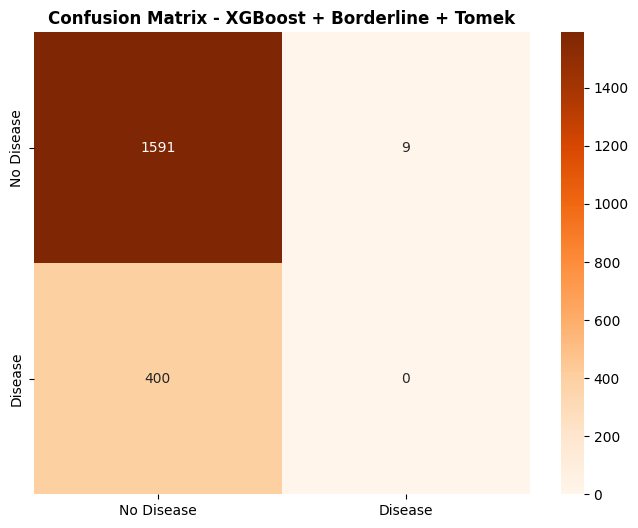

✓ Saved: XGBoost/models/XGBoost_borderline_tomek_fold1.pkl
✓ Saved: XGBoost/models/borderline_tomek_sampler_xgb.pkl
✓ Saved model


In [12]:
from imblearn.over_sampling import BorderlineSMOTE

print("-" * 30)
print('XGBoost + BorderlineSMOTE + Tomek Links')
print("-" * 30)

# 1. Apply Pipeline
pipe_bt = ImbPipeline([
    ('borderline', BorderlineSMOTE(random_state=42, kind='borderline-2')),
    ('tomek', TomekLinks())
])
print("Resampling with BorderlineSMOTE + Tomek...")
X_train_bt, y_train_bt = pipe_bt.fit_resample(X_train, y_train.values.ravel())

print(f"Original size: {len(X_train)}")
print(f"After Borderline+Tomek size: {len(X_train_bt)}")
print("-" * 30)

# 2. Train Model
xgb_bt = XGBClassifier(
    n_estimators=100, random_state=42,
    use_label_encoder=False, eval_metric='logloss'
)
xgb_bt.fit(X_train_bt, y_train_bt)

# 3. Cross-Validation
cv_scores = []

# Cross-validation with Borderline+Tomek and best-fold selection
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []
best_model_xgb_borderline_tomek = None
best_score_xgb_borderline_tomek = -1.0
best_fold_idx_xgb_borderline_tomek = -1

X_train_np = X_train.values if hasattr(X_train, 'values') else X_train
y_train_np = y_train.values.ravel() if hasattr(y_train, 'values') else y_train

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train_np, y_train_np)):
    X_train_fold, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_train_fold, y_val_fold = y_train_np[train_idx], y_train_np[val_idx]
    
    try:
        X_train_fold_bt, y_train_fold_bt = pipe_bt.fit_resample(X_train_fold, y_train_fold)
    # Safe check for slicing
        if hasattr(X_train_fold_bt, 'iloc'):
            X_train_fold_bt_data = X_train_fold_bt
        else:
            X_train_fold_bt_data = X_train_fold_bt
        
        xgb_fold = XGBClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=6,
            random_state=42,
            eval_metric='logloss'
        )
        xgb_fold.fit(X_train_fold_bt_data, y_train_fold_bt)
        score = xgb_fold.score(X_val_fold, y_val_fold)
        cv_scores.append(score)
        
        # Track best fold
        if score > best_score_xgb_borderline_tomek:
            best_model_xgb_borderline_tomek = xgb_fold
            best_score_xgb_borderline_tomek = score
            best_fold_idx_xgb_borderline_tomek = fold + 1
    except ValueError as e:
        print(f"Warning in fold: {e}")
        continue
    
print("-" * 30)
print(f"Cross-Validation Scores (Total {len(cv_scores)} Folds):")
print("-" * 30)
for i, score in enumerate(cv_scores):
    print(f"Fold {i+1}: {score:.4f}  ({score*100:.2f}%)")

print("-" * 30)
print(f">> Average CV Accuracy: {np.mean(cv_scores):.4f}")
print("-" * 30)

# 4. Evaluation
print("-" * 30)
print(f'>> Average CV Accuracy: {np.mean(cv_scores):.4f} (± {np.std(cv_scores):.4f})')
print("-" * 30)

# Use best fold model for test evaluation
print(f"✓ Selected best model from Fold {best_fold_idx_xgb_borderline_tomek}")
print("-" * 30)

X_test_np = X_test.values if hasattr(X_test, 'values') else X_test

# Predictions using best-fold model
y_pred = best_model_xgb_borderline_tomek.predict(X_test_np)
y_pred_proba = best_model_xgb_borderline_tomek.predict_proba(X_test_np)[:, 1]

test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)
test_roc_auc = roc_auc_score(y_test, y_pred_proba)

print("\n" + "=" * 50)
print("TEST SET PERFORMANCE (Borderline + Tomek) - Fold {}".format(best_fold_idx_xgb_borderline_tomek))
print("=" * 50)
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1-Score:  {test_f1:.4f}")
print(f"ROC-AUC:   {test_roc_auc:.4f}")
print("=" * 50)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['No Disease', 'Disease'], 
            yticklabels=['No Disease', 'Disease'])
plt.title('Confusion Matrix - XGBoost + Borderline + Tomek', fontweight='bold')
plt.show()

# Save Results
xgb_borderline_tomek_results = {
    'Model': 'XGBoost', 'Sampling': 'Borderline+Tomek',
        'Best_Fold': best_fold_idx_xgb_borderline_tomek,
    'CV_Accuracy': np.mean(cv_scores), 'CV_Std': np.std(cv_scores),
    'Test_Accuracy': test_accuracy, 'Precision': test_precision,
    'Recall': test_recall, 'F1_Score': test_f1, 'ROC_AUC': test_roc_auc
}

joblib.dump(xgb_bt, 'XGBoost/models/XGB_borderline_tomek.pkl')
joblib.dump(best_model_xgb_borderline_tomek, 'XGBoost/models/XGBoost_borderline_tomek_fold{}.pkl'.format(best_fold_idx_xgb_borderline_tomek))
joblib.dump(pipe_bt, 'XGBoost/models/borderline_tomek_sampler_xgb.pkl')
print("✓ Saved: XGBoost/models/XGBoost_borderline_tomek_fold{}.pkl".format(best_fold_idx_xgb_borderline_tomek))
print("✓ Saved: XGBoost/models/borderline_tomek_sampler_xgb.pkl")
print("✓ Saved model")


XGBOOST - COMPREHENSIVE SUMMARY
  Model           Sampling  Best_Fold  CV_Accuracy   CV_Std  Test_Accuracy  Precision  Recall  F1_Score  ROC_AUC
XGBoost    None (Baseline)          4     0.799125 0.001403         0.7995   0.333333  0.0025  0.004963 0.471533
XGBoost              SMOTE          4     0.796500 0.001879         0.7980   0.166667  0.0025  0.004926 0.495327
XGBoost             ADASYN          2     0.797375 0.000729         0.7960   0.000000  0.0000  0.000000 0.488909
XGBoost RandomUnderSampler          1     0.494375 0.022354         0.4985   0.192661  0.4725  0.273715 0.494325
XGBoost         SMOTETomek          2     0.798000 0.001500         0.7965   0.230769  0.0075  0.014528 0.483523
XGBoost           SMOTEENN          5     0.524500 0.013178         0.5220   0.194505  0.4425  0.270229 0.504834
XGBoost           NearMiss          3     0.390875 0.008203         0.3910   0.199265  0.6775  0.307955 0.508578
XGBoost       ADASYN+Tomek          1     0.797875 0.000306    

/var/folders/pb/8b1j14m116723lhg0z_g3nnm0000gn/T/ipykernel_16725/121214306.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xgb_df['Sampling'], rotation=45, ha='right')
/var/folders/pb/8b1j14m116723lhg0z_g3nnm0000gn/T/ipykernel_16725/121214306.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xgb_df['Sampling'], rotation=45, ha='right')
/var/folders/pb/8b1j14m116723lhg0z_g3nnm0000gn/T/ipykernel_16725/121214306.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xgb_df['Sampling'], rotation=45, ha='right')
/var/folders/pb/8b1j14m116723lhg0z_g3nnm0000gn/T/ipykernel_16725/121214306.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after

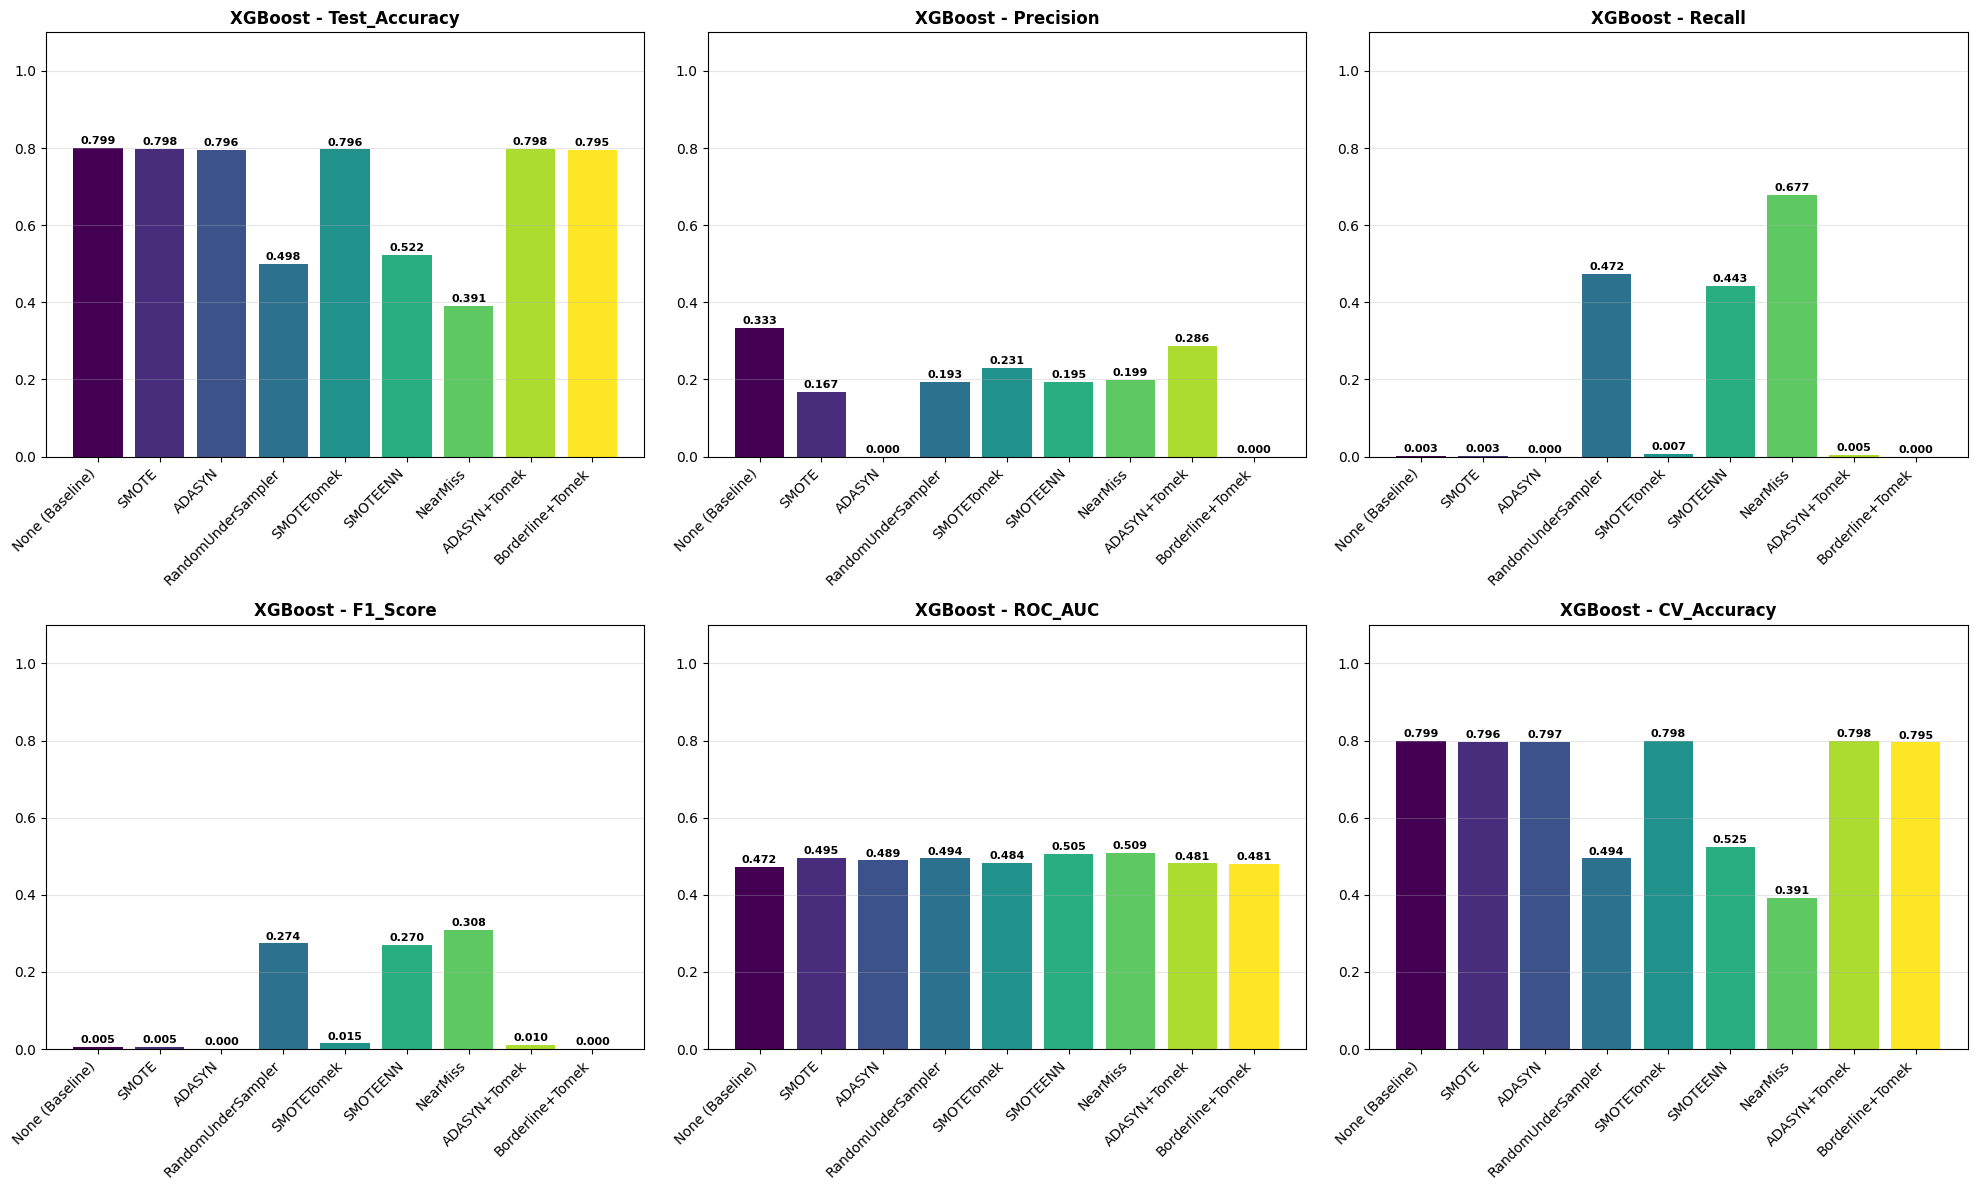


🏆 BEST XGBOOST MODEL
Best by F1-Score: NearMiss (0.3080)


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

# 1. รวบรวมผลลัพธ์ (เช็คชื่อตัวแปรเก่าให้ครบนะครับ)
xgb_all_results = [
    xgb_baseline_results,
    xgb_smote_results,
    xgb_adasyn_results,
    xgb_rus_results,
    xgb_smote_tomek_results,
    xgb_smote_enn_results,
    xgb_nearmiss_results,
    xgb_adasyn_tomek_results,
    xgb_borderline_tomek_results
]

# 2. สร้าง DataFrame
xgb_df = pd.DataFrame(xgb_all_results)

print("\n" + "=" * 90)
print("XGBOOST - COMPREHENSIVE SUMMARY")
print("=" * 90)
print(xgb_df.to_string(index=False))

# 3. Save CSV
os.makedirs('XGBoost/models', exist_ok=True)
xgb_df.to_csv('XGBoost/models/xgb_summary.csv', index=False)
print("✓ Saved summary CSV")

# 4. Visualization
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()
metrics = ['Test_Accuracy', 'Precision', 'Recall', 'F1_Score', 'ROC_AUC', 'CV_Accuracy']
colors = plt.cm.viridis(np.linspace(0, 1, len(xgb_df)))

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    if metric in xgb_df.columns:
        bars = ax.bar(xgb_df['Sampling'], xgb_df[metric], color=colors)
        ax.set_title(f'XGBoost - {metric}', fontsize=12, fontweight='bold')
        ax.set_xticklabels(xgb_df['Sampling'], rotation=45, ha='right')
        ax.set_ylim([0, 1.1])
        ax.grid(axis='y', alpha=0.3)
        
        for bar in bars:
            ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01, 
                    f'{bar.get_height():.3f}', ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('XGBoost/models/xgb_comparison_plot.png', dpi=300)
plt.show()

# 5. Best Model Recommendation
print("\n" + "=" * 90)
print("🏆 BEST XGBOOST MODEL")
print("=" * 90)
best_f1_idx = xgb_df['F1_Score'].idxmax()
print(f"Best by F1-Score: {xgb_df.loc[best_f1_idx, 'Sampling']} ({xgb_df.loc[best_f1_idx, 'F1_Score']:.4f})")